#### Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Import Datasets

In [15]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test

#### Support Vector Machine

In [16]:
#param_grid = {
#    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
#    'C': [0.001, 0.01, 0.1, 1, 10, 100],
#    'gamma': [0.001, 0.01, 0.1, 1, 10]
#}

#svr = SVR()

#grid_search = GridSearchCV(svr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
#grid_search.fit(Set1_X_Train_scaled, Set1_y_Train)

#best_kernel = grid_search.best_params_['kernel']
#best_C = grid_search.best_params_['C']
#best_gamma = grid_search.best_params_['gamma']
#best_score = -grid_search.best_score_  

#print("Best Kernel:", best_kernel)
#print("Best C:", best_C)
#print("Best gamma:", best_gamma)
#print("Best Score (MSE):", best_score)

#mean_test_scores = grid_search.cv_results_['mean_test_score']
#params = grid_search.cv_results_['params']

#for param, score in zip(params, mean_test_scores):
    #print(f"Kernel: {param['kernel']}, C: {param['C']}, Gamma: {param['gamma']}, Mean Test MSE: {-score}")

In [25]:
svm_reg = SVR(kernel='rbf', C=10, gamma=0.01)

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

svm_reg.fit(Set1_X_Train_scaled, Set1_y_Train_array)

svm_reg_pred_train = svm_reg.predict(Set1_X_Train_scaled)
svm_reg_pred_test = svm_reg.predict(Set1_X_Test_scaled)

#### Support Vector Machine Evaluation 

In [26]:
# Mean Squared Error
mse_train_svm = mean_squared_error(Set1_y_Train_array, svm_reg_pred_train)
mse_test_svm = mean_squared_error(Set1_y_Test_array, svm_reg_pred_test)

# Root Mean Squared Error
rmse_train_svm = np.sqrt(mse_train_svm)
rmse_test_svm = np.sqrt(mse_test_svm)

# Mean Absolute Error
mae_train_svm = mean_absolute_error(Set1_y_Train_array, svm_reg_pred_train)
mae_test_svm = mean_absolute_error(Set1_y_Test_array, svm_reg_pred_test)

# R2 Score
r2_train_svm = r2_score(Set1_y_Train_array, svm_reg_pred_train)
r2_test_svm = r2_score(Set1_y_Test_array, svm_reg_pred_test)

# Coefficient of Determination
cod_train_svm = explained_variance_score(Set1_y_Train_array, svm_reg_pred_train)
cod_test_svm = explained_variance_score(Set1_y_Test_array, svm_reg_pred_test)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_svm)
print("Root Mean Squared Error:", rmse_train_svm)
print("Mean Absolute Error:", mae_train_svm)
print("R-squared Score:", r2_train_svm)
print("Coefficient of Determination:", cod_train_svm)

# Testing Set
print("--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_svm)
print("Root Mean Squared Error:", rmse_test_svm)
print("Mean Absolute Error:", mae_test_svm)
print("R-squared Score:", r2_test_svm)
print("Coefficient of Determination:", cod_test_svm)

--Training Set Evaluation--
Mean Squared Error: 2132.2032849290044
Root Mean Squared Error: 46.17578678191639
Mean Absolute Error: 33.63728484596601
R-squared Score: 0.5505815515378488
Coefficient of Determination: 0.5663084279083486
--Testing Set Evaluation--
Mean Squared Error: 1284.9891343328343
Root Mean Squared Error: 35.846745100954905
Mean Absolute Error: 29.015335491599657
R-squared Score: 0.25588525367935444
Coefficient of Determination: 0.2559590984559965


#### Plot Evaluation Results

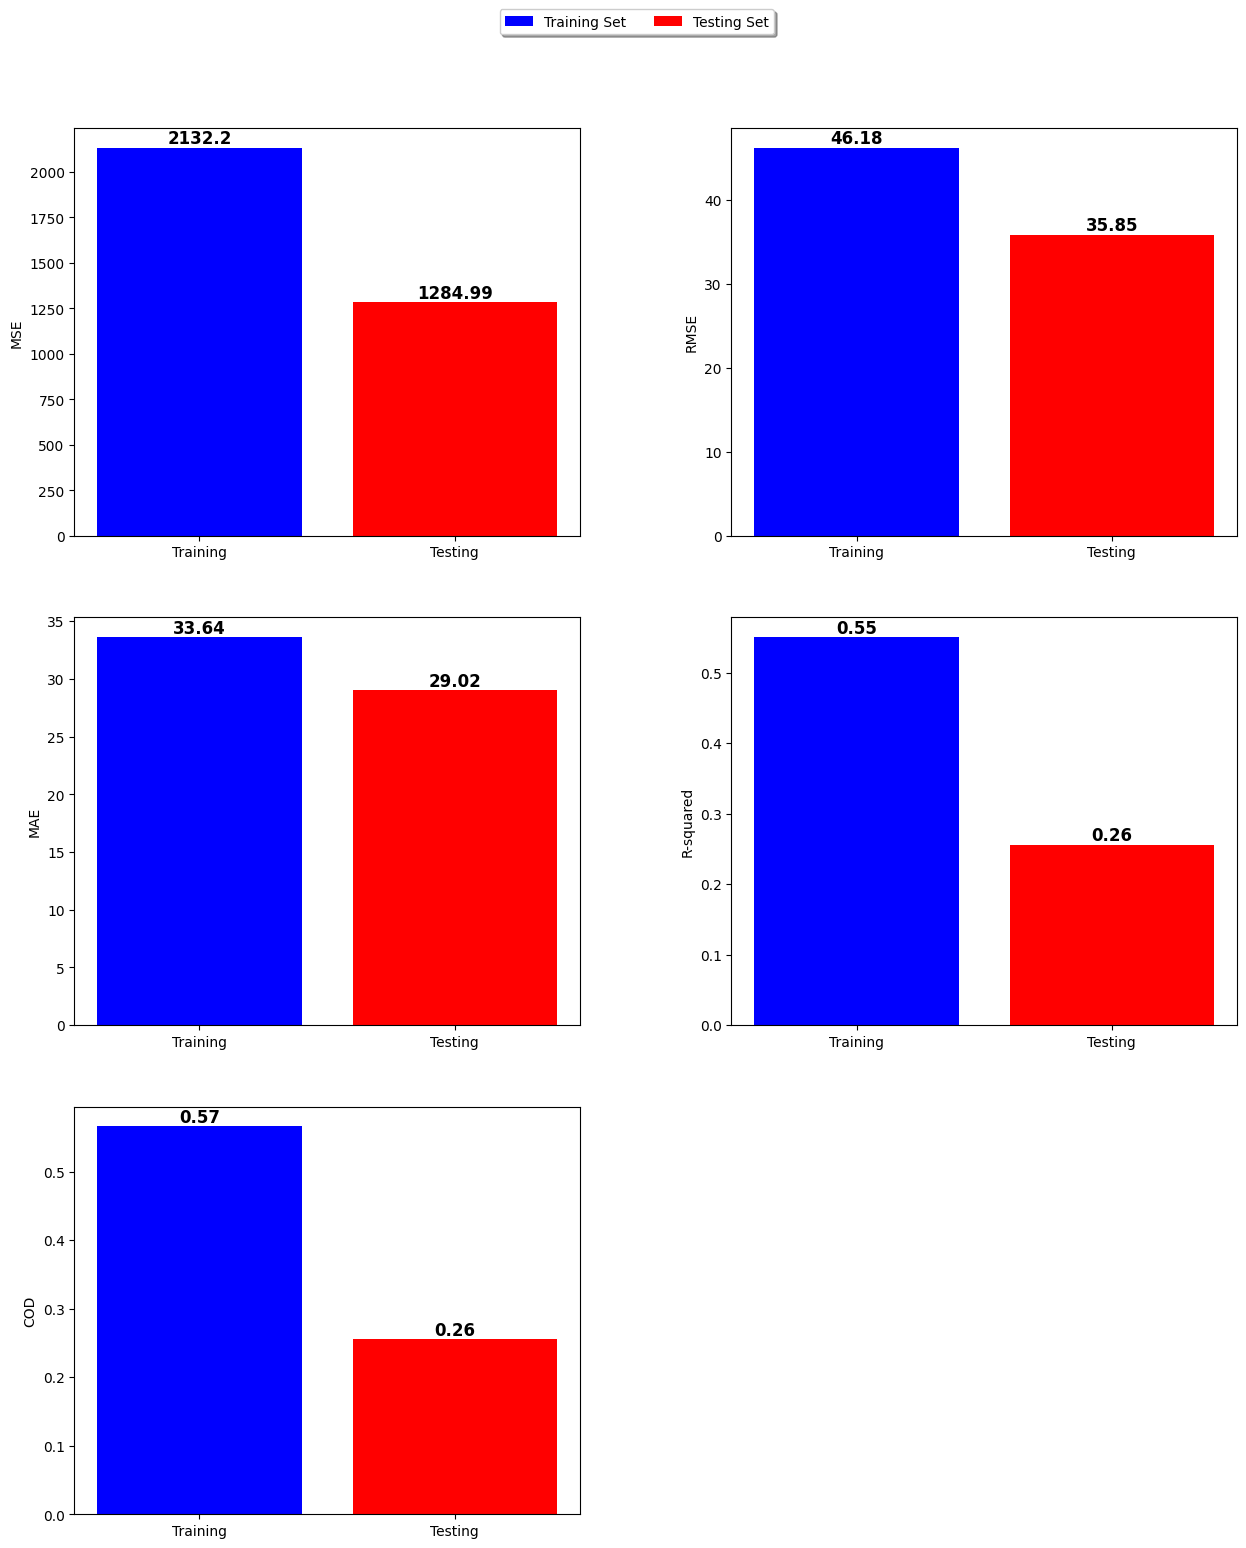

In [27]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_svm, rmse_train_svm, mae_train_svm, r2_train_svm, cod_train_svm]
test_metrics = [mse_test_svm, rmse_test_svm, mae_test_svm, r2_test_svm, cod_test_svm]

num_metrics = len(metrics)
num_cols = 2
num_rows = (num_metrics + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i // num_cols, i % num_cols]
    ax.bar('Training', train_metric, color='b', label='Training Set')
    ax.bar('Testing', test_metric, color='r', label='Testing Set')
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Position the legend in the middle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

for i in range(num_metrics, num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.subplots_adjust(wspace=0.3)
plt.show()